# Generative admixture correction on Xenium breast 5K

Molecules leak between neighboring cells, so a cell's counts mix its own
expression with material from the cells around it — but cells also change
their own transcription in response to their neighborhood, and a
correction that flattens every neighbor-linked gradient erases that
biology. The generative model separates the two: it decomposes each
cell's counts into the cell's own expression programs, contamination from
each neighboring cell type, ambient background, and neighborhood-induced
expression, then removes the contamination and ambient shares while
keeping the induced ones (see `docs/generative.md` for the model and its
validation).

This notebook runs the model on the Xenium breast 5K dataset (688,099
cells, 5,101 genes) and characterizes both sides of the separation: the
pattern of material moving between cell types, and the induced programs
the correction preserves.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from celladmix import CellAdmix, read_annotation

In [2]:
data_dir = Path("data")
output_dir = Path("out_python")
num_threads = 10

annotation_table = pd.read_csv(Path("annotations") / "annotation.csv.gz")
annotation_table = annotation_table[annotation_table["merged_annotation"] != "Ambiguous / low-quality"]
annotation = read_annotation(annotation_table, annotation_col="merged_annotation")

ds = CellAdmix(data_dir, output_dir=output_dir, annotation=annotation, num_threads=num_threads)
nmf_fit = ds.fit(nmf_variant="invsqrt_kl", verbose=False)
nmf_fit

CellAdmixFit(run_path='out_python/runs/fit_rank8_invsqrt_kl', n_factors=8, n_cells=688099)

## The admixture pattern between cell types

The audit estimates, for every ordered pair of cell types, how many
molecules leaked from the source type into cells of the target type,
using the rise of source-marker content with the number of source-type
neighbors.

Excluded 53 likely induced genes from marker panels (exposure-linked excess far above the source-profile expectation): BIRC3, CCL2, DCN, CTSL, CDKN1A, MAN1A1, ALPL, DUSP6


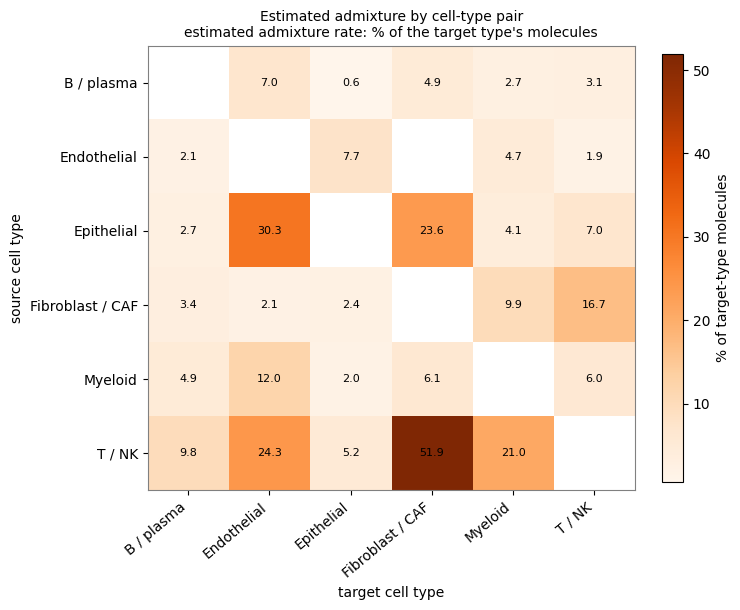

In [3]:
audit = nmf_fit.audit_admixture()
fig, ax = plt.subplots(figsize=(7.5, 6.2))
audit.plot_map(ax=ax)
fig.tight_layout()

In [4]:
pairs = audit.pairs(detected_only=True)
pairs.sort_values("rate", ascending=False)[
    ["source", "target", "admixed_molecules", "rate"]].head(8)

,source,target,admixed_molecules,rate
28,T / NK,Fibroblast / CAF,442426,0.519492
11,Epithelial,Endothelial,386562,0.303065
26,T / NK,Endothelial,309479,0.242632
12,Epithelial,Fibroblast / CAF,201107,0.236138
29,T / NK,Myeloid,1910340,0.209720
19,Fibroblast / CAF,T / NK,1426783,0.167255
21,Myeloid,Endothelial,153152,0.120071
18,Fibroblast / CAF,Myeloid,897665,0.098547


Aggregated over targets, the estimated shedding by source type:

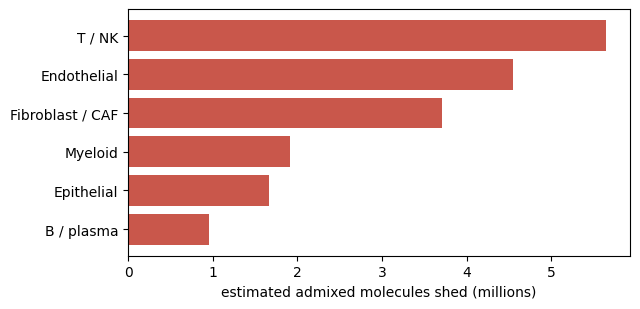

In [5]:
by_source = pairs.groupby("source")["admixed_molecules"].sum().sort_values()
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.barh(by_source.index, by_source / 1e6, color="#c0392b", alpha=0.85)
ax.set_xlabel("estimated admixed molecules shed (millions)")
fig.tight_layout()

## Correcting with the generative model

The model is fitted on the audit's detected pairs (the NMF fit only
initializes its expression programs), and the correction derives from
the fitted model; on this dataset — the largest of the examples — the
fit takes a few minutes.

In [6]:
model = audit.fit_generative(init=nmf_fit, num_threads=num_threads)
correction = model.correct()
model.pairs.sort_values("removed_molecules_expected", ascending=False).head(6)

,source,target,estimated_dose_molecules,removed_molecules_expected,induced_molecules,mean_dose_exposed
23,T / NK,Myeloid,1.938263e+06,1.843809e+06,18143.829062,0.241925
14,T / NK,Epithelial,1.908858e+06,1.695358e+06,21380.048301,0.121957
26,Epithelial,T / NK,5.702540e+05,5.482185e+05,0.000000,0.075665
6,Epithelial,Endothelial,4.695744e+05,4.498409e+05,0.000000,0.415262
13,Myeloid,Epithelial,4.478542e+05,4.267753e+05,84140.308426,0.025390
4,T / NK,B / plasma,4.298904e+05,3.979872e+05,5.228994,0.129961


The model's central quantity is the per-cell contamination fraction:
how much of each cell's content arrived from each source. Its dependence
on the number of source neighbors, for the largest pair, and the same
fractions drawn in space:

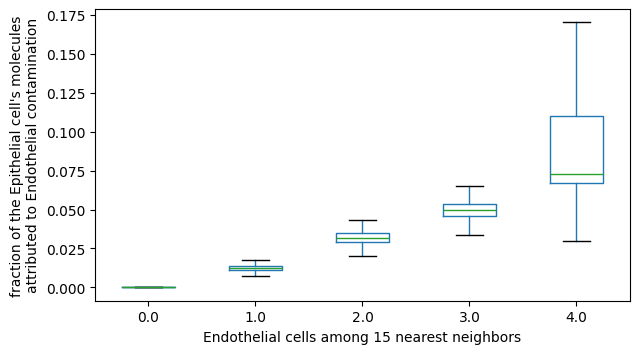

In [7]:
top = pairs.sort_values("admixed_molecules", ascending=False).iloc[0]
comp = model.composition(top["source"], top["target"])

from celladmix._score_utils import source_exposure_counts
cells_xy = nmf_fit.cell_factors()
expo_all, types = source_exposure_counts(cells_xy, ds.annotation, neighbor_k=15)
expo = pd.Series(expo_all[:, types.index(top["source"])],
                 index=cells_xy["cell_id"].astype(str))
comp["exposure"] = np.minimum(expo.reindex(comp["cell_id"]).to_numpy(), 4)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
comp.boxplot(column="contamination", by="exposure", ax=ax, grid=False,
             showfliers=False)
ax.set_xlabel(f"{top['source']} cells among 15 nearest neighbors")
ax.set_ylabel(f"fraction of the {top['target']} cell's molecules\n"
              f"attributed to {top['source']} contamination")
ax.set_title(""); fig.suptitle("")
fig.tight_layout()

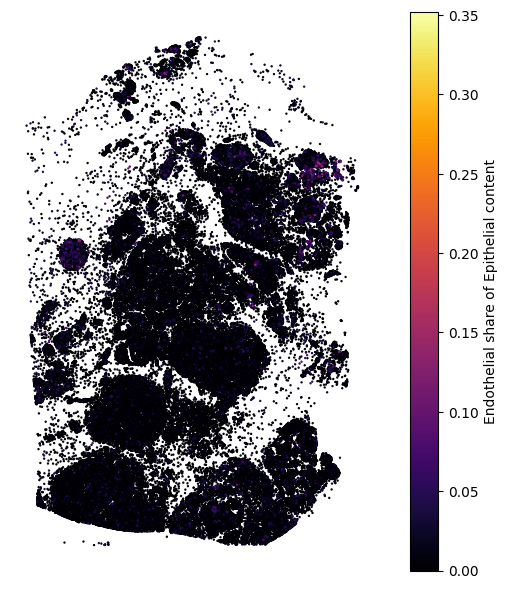

In [8]:
xy = cells_xy.set_index(cells_xy["cell_id"].astype(str)).reindex(comp["cell_id"])
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(xy["x"], xy["y"], c=np.minimum(comp["contamination"], 0.5),
                s=0.5, cmap="inferno", rasterized=True)
ax.set_aspect("equal"); ax.axis("off")
fig.colorbar(sc, ax=ax, fraction=0.04,
             label=f"{top['source']} share of {top['target']} content")
fig.tight_layout()

## The induction pattern

The model retains genes whose exposure-linked excess exceeds what
transfer from the source can deliver — expression the target cells
switched on themselves. On this tissue the retained set is led by
inflammatory-response and myoepithelial contractile programs:

In [9]:
induced = model.induced
induced.sort_values("excess", ascending=False)[
    ["source", "target", "gene", "excess", "fold", "z"]].head(10)

,source,target,gene,excess,fold,z
168,T / NK,Myeloid,BIRC3,20617.312078,2.594155,10.236147
111,Myeloid,Epithelial,MYL9,7538.403361,3.295867,13.646669
71,Myeloid,Epithelial,DST,7149.335356,10.780259,41.193433
140,T / NK,Epithelial,MS4A1,6256.067911,3.050044,13.078824
50,B / plasma,Epithelial,MYH9,4579.620639,3.366079,12.129530
1,Myeloid,B / plasma,CCL2,4275.419647,4.206570,12.376512
0,Myeloid,B / plasma,C11orf96,4062.314001,5.112616,12.383496
2,Myeloid,B / plasma,CDKN1A,4003.719416,5.104830,11.094569
97,Myeloid,Epithelial,ANXA2,3994.816370,3.112510,10.309481
153,B / plasma,Myeloid,ADAMTS1,3798.336112,2.739642,10.724606


The distinction gene by gene, for the pair with the strongest
induced signal: a transferred marker gene's rise with exposure is
flattened to the unexposed level, while the induced gene keeps its
gradient and loses only the transferred share.

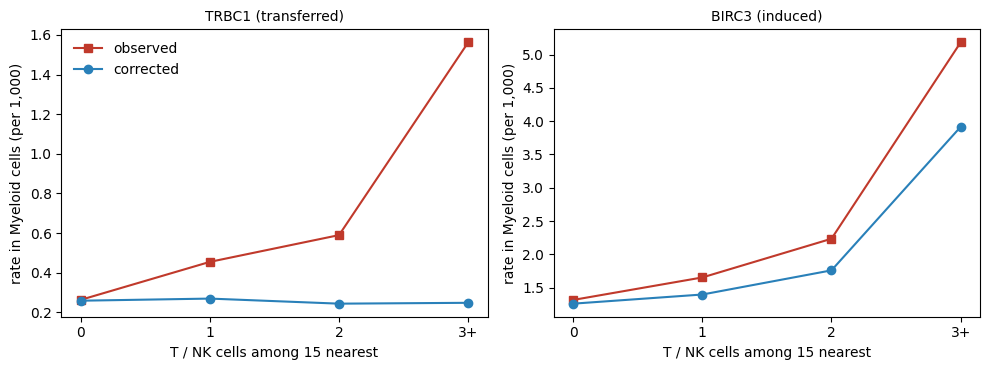

In [10]:
ind_top = induced.sort_values("excess", ascending=False).iloc[0]
mk = audit.markers(ind_top["source"], ind_top["target"])
transfer_gene = next(g for g in mk["pool"] if g not in set(induced["gene"]))

before, genes, cell_ids = nmf_fit.counts()
after, _, _ = correction.counts()
gi = {g: i for i, g in enumerate(genes)}
ci = pd.Index([str(c) for c in cell_ids])
comp_t = model.composition(ind_top["source"], ind_top["target"])
cols = ci.get_indexer(comp_t["cell_id"])
tot = np.asarray(before[:, cols].sum(axis=0)).ravel()
expo_t = np.minimum(pd.Series(expo_all[:, types.index(ind_top["source"])],
    index=cells_xy["cell_id"].astype(str)).reindex(comp_t["cell_id"]).to_numpy(), 3)

def rate_by_bin(matrix, gene):
    v = np.asarray(matrix[gi[gene]][:, cols].todense()).ravel()
    return [v[expo_t == b].sum() / max(tot[expo_t == b].sum(), 1) * 1e3
            for b in range(4)]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, gene, label in [(axes[0], transfer_gene, "transferred"),
                        (axes[1], ind_top["gene"], "induced")]:
    ax.plot(range(4), rate_by_bin(before, gene), "s-", color="#c0392b",
            label="observed")
    ax.plot(range(4), rate_by_bin(after, gene), "o-", color="#2980b9",
            label="corrected")
    ax.set_title(f"{gene} ({label})", fontsize=10)
    ax.set_xlabel(f"{ind_top['source']} cells among 15 nearest")
    ax.set_ylabel(f"rate in {ind_top['target']} cells (per 1,000)")
    ax.set_xticks(range(4), ["0", "1", "2", "3+"])
axes[0].legend(frameon=False)
fig.tight_layout()

## Verification

The correction is verified against the audit's own measurements, like
any other correction in the package. On a panel this large, shared-gene
pairs stay partly uncorrected by design — the model never removes a
target type's own marker genes, whose contamination is indistinguishable
from native expression.

In [11]:
report = audit.evaluate(correction)
report.summary()

/tmp/ipykernel_1883355/346086481.py:1: UserWarning: Correction removed only 7% of the estimated ~1,426,783 admixed molecules from Fibroblast / CAF into T / NK
  report = audit.evaluate(correction)


{'detected_pairs': 29,
 'estimated_admixed_molecules': 18430537,
 'leakage_removed_overall': np.float64(0.6928634515921573),
 'median_pair_sensitivity': 0.915978376046309,
 'own_marker_false_removal': 0.0}

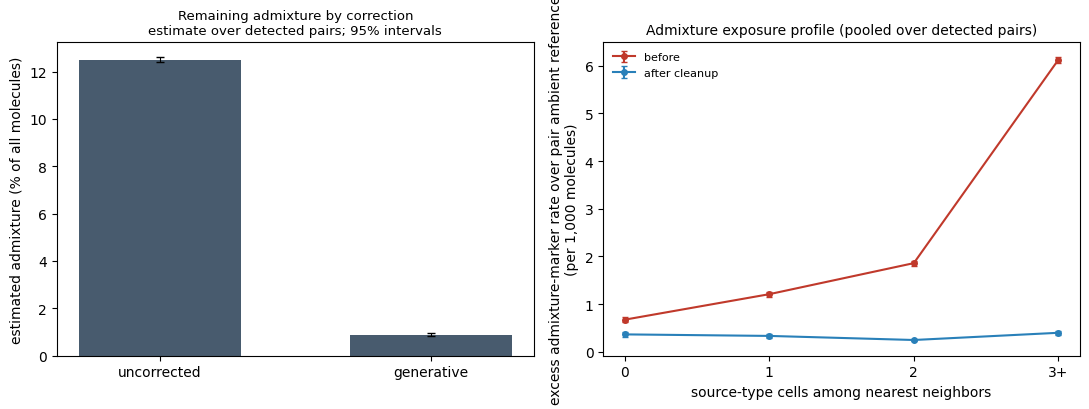

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
audit.plot_remaining({"generative": correction}, ax=axes[0])
audit.plot_exposure(correction=correction, ax=axes[1])
fig.tight_layout()

Induced expression is only recognizable when it is disproportionate
to the source's transfer profile; induction of a source's own top marker
genes cannot be told apart from admixture at count level and is removed
with it — see the identifiability limit in `docs/generative.md`.